# Random Walks: 1D and 2D

This notebook uses the f2py wrapper `random_walks.f90` to simulate unbiased 1D and 2D lattice random walks. The main check is the diffusive scaling $\langle r^2(n)\rangle \sim n$.

## Compile the f2py module

Run this cell from inside the `python/` folder. It compiles the Fortran source from `../f2py_interfaces/random_walks.f90`.

## Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random_walks

## Run a 2D random walk ensemble

In [3]:
dim = 2
nsteps = 1000
ens = 10000

xstore = np.zeros((ens, nsteps+1), dtype=np.float32, order="F")
ystore = np.zeros((ens, nsteps+1), dtype=np.float32, order="F")
times  = np.zeros(nsteps+1, dtype=np.float32, order="F")

xstore, ystore, times = random_walks.random_walk_store(
    dim, nsteps, ens, xstore, ystore, times
)

msd = np.mean(xstore**2 + ystore**2, axis=0)
meanx = np.mean(xstore, axis=0)
meany = np.mean(ystore, axis=0)

## Mean displacement

For an unbiased random walk, both $\langle x(n)\rangle$ and $\langle y(n)\rangle$ should remain close to zero.

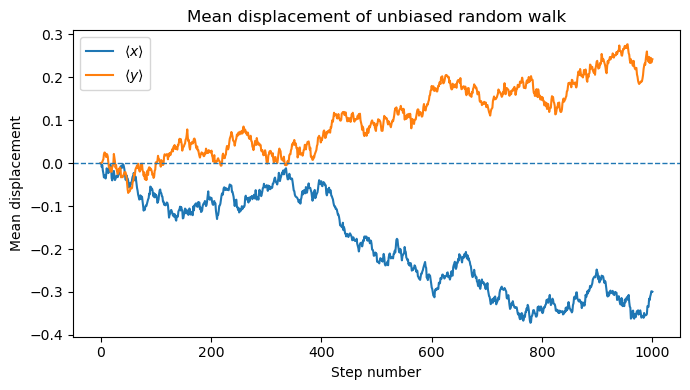

In [4]:
plt.figure(figsize=(7,4))
plt.plot(times, meanx, label=r"$\langle x \rangle$")
plt.plot(times, meany, label=r"$\langle y \rangle$")
plt.axhline(0, lw=1, ls="--")
plt.xlabel("Step number")
plt.ylabel("Mean displacement")
plt.title("Mean displacement of unbiased random walk")
plt.legend()
plt.tight_layout()
plt.show()

## Mean-squared displacement

For both the 1D unit-step walk and the 2D square-lattice walk with one unit move per step, the theoretical result is approximately $\langle r^2(n)\rangle = n$.

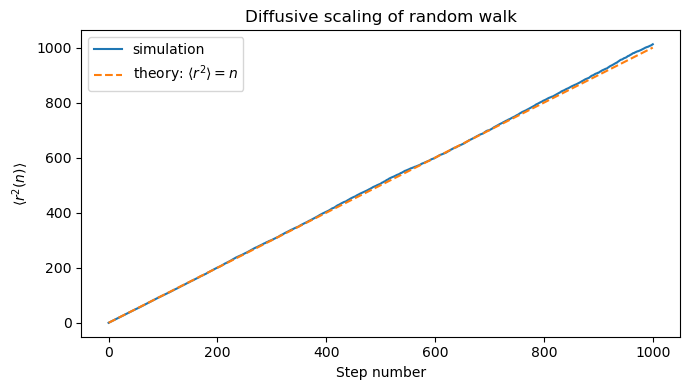

In [5]:
theory = times

plt.figure(figsize=(7,4))
plt.plot(times, msd, label="simulation")
plt.plot(times, theory, "--", label=r"theory: $\langle r^2\rangle=n$")
plt.xlabel("Step number")
plt.ylabel(r"$\langle r^2(n)\rangle$")
plt.title("Diffusive scaling of random walk")
plt.legend()
plt.tight_layout()
plt.show()

## Sample trajectories

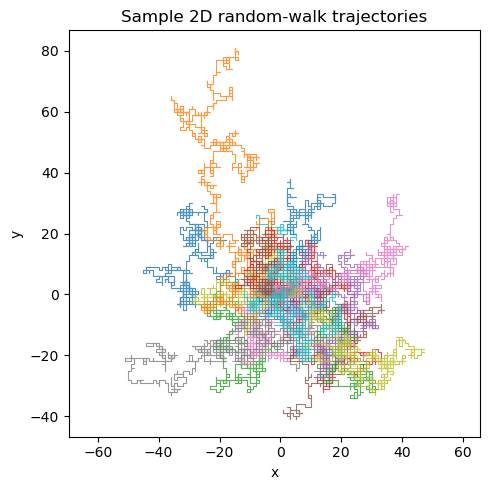

In [6]:
plt.figure(figsize=(5,5))
for k in range(20):
    plt.plot(xstore[k], ystore[k], lw=0.8, alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sample 2D random-walk trajectories")
plt.axis("equal")
plt.tight_layout()
plt.show()

## Final-position distribution

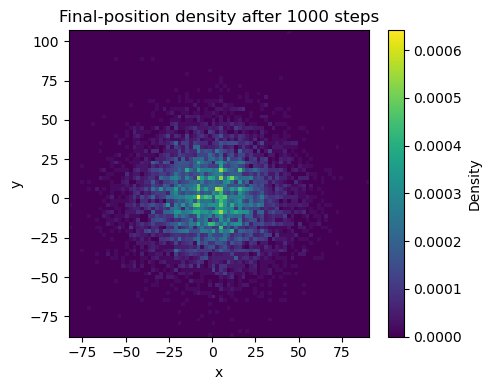

In [7]:
plt.figure(figsize=(5,4))
plt.hist2d(xstore[:,-1], ystore[:,-1], bins=80, density=True)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Final-position density after {nsteps} steps")
plt.colorbar(label="Density")
plt.tight_layout()
plt.show()

## 1D check

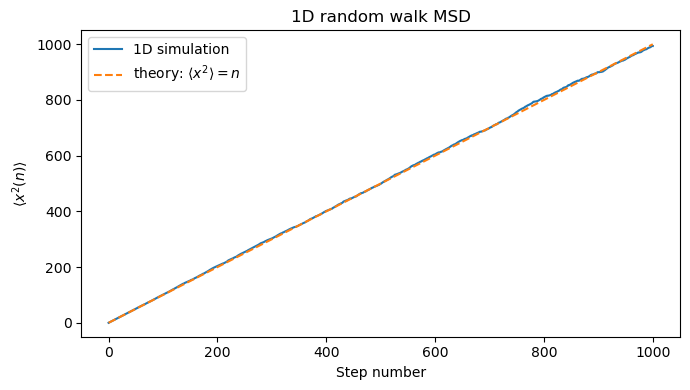

In [8]:
dim = 1
x1 = np.zeros((ens, nsteps+1), dtype=np.float32, order="F")
y1 = np.zeros((ens, nsteps+1), dtype=np.float32, order="F")
t1 = np.zeros(nsteps+1, dtype=np.float32, order="F")

x1, y1, t1 = random_walks.random_walk_store(dim, nsteps, ens, x1, y1, t1)
msd1 = np.mean(x1**2, axis=0)

plt.figure(figsize=(7,4))
plt.plot(t1, msd1, label="1D simulation")
plt.plot(t1, t1, "--", label=r"theory: $\langle x^2\rangle=n$")
plt.xlabel("Step number")
plt.ylabel(r"$\langle x^2(n)\rangle$")
plt.title("1D random walk MSD")
plt.legend()
plt.tight_layout()
plt.show()